In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from scipy.stats import multivariate_normal

### sampling from a bivariate mixture distribution

C:\tools\Manim\Lib\site-packages\scipy\stats\_multivariate.py:758: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  out = random_state.multivariate_normal(mean, cov, size)


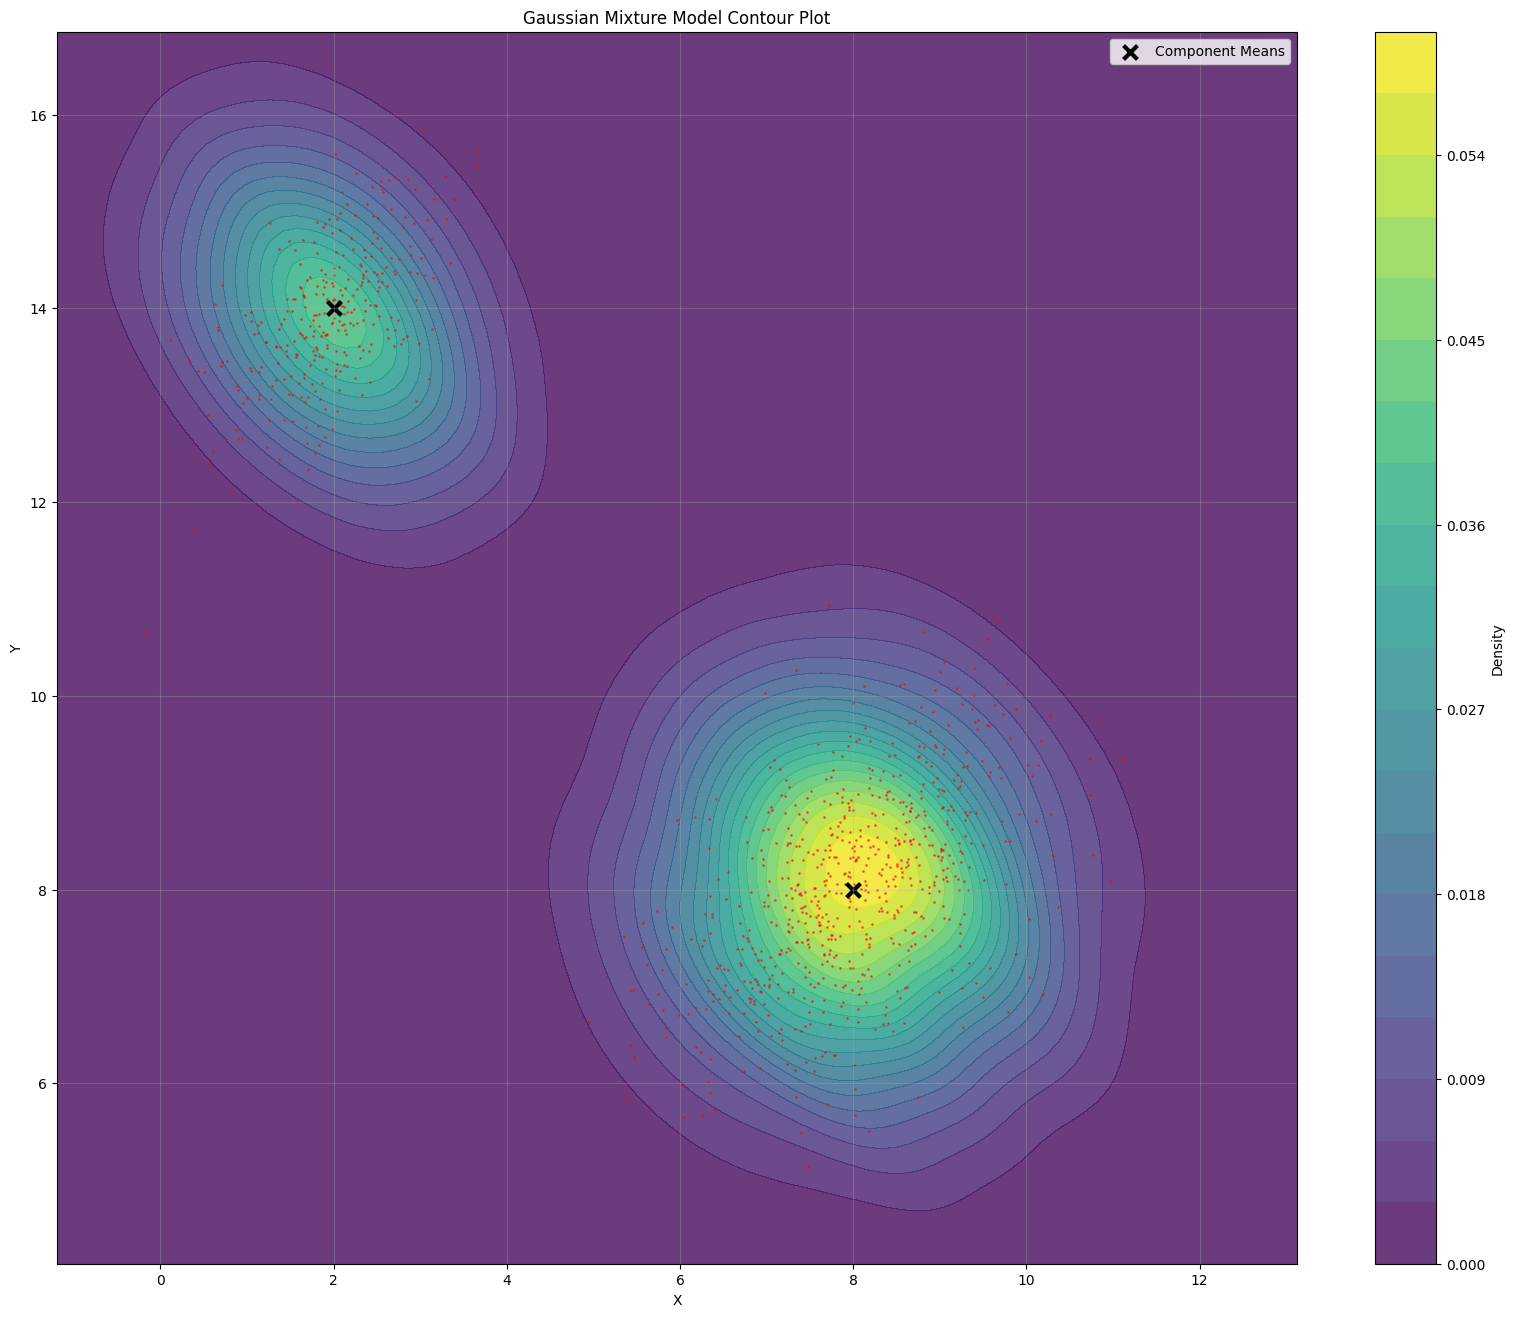

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_gmm_contour(samples, m):
    # Convert to numpy array if it's a torch tensor
    if torch.is_tensor(samples):
        samples = samples.numpy()
    
    # Create a meshgrid for contour plotting
    x_min, x_max = samples[:, 0].min() - 1, samples[:, 0].max() + 1
    y_min, y_max = samples[:, 1].min() - 1, samples[:, 1].max() + 1
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    
    # Calculate the kernel density estimate
    positions = np.vstack([xx.ravel(), yy.ravel()])
    kernel = gaussian_kde(samples.T)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    # Create the plot
    plt.figure(figsize=(20, 16))
    
    # Plot the contour
    plt.contourf(xx, yy, f, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(label='Density')
    
    # Plot the samples as scatter points
    plt.scatter(samples[:, 0], samples[:, 1], c='red', alpha=0.5, s=1)
    
    # Plot the means
    means = np.array(m)
    plt.scatter(means[:, 0], means[:, 1], c='black', marker='x', s=100, 
                linewidth=3, label='Component Means')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Gaussian Mixture Model Contour Plot')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

# Usage

# Data generation functions
def sample_gmm(n, weights, means, sds):
    #Generate samples from a Gaussian Mixture Model
    components = np.random.choice(len(weights), size=n, p=weights)
    sample_mean = np.array(means)[components]
    sample_sds = np.array(sds)[components]
    samples = np.array([multivariate_normal.rvs(sample_mean[i], sample_sds[i]) for i in range(n)])
    return torch.tensor(samples, dtype=torch.float32)

m = [[2, 14], 
        [8, 8]]

s = [[[0.3, 0.1], [0.3, 0.5]],
     [[1.0, 0.5], [0.5, 1.0]]] 

w = [0.3, 0.7]

gmm_samples = sample_gmm(1000, w, m, s)


plot_gmm_contour(gmm_samples, m)

In [3]:
# Data generation functions
def sample_gmm(n, weights, means, sds):
    #Generate samples from a Gaussian Mixture Model
    components = np.random.choice(len(weights), size=n, p=weights)
    sample_mean = np.array(means)[components]
    sample_sds = np.array(sds)[components]
    samples = np.array([multivariate_normal.rvs(sample_mean[i], sample_sds[i]) for i in range(n)])
    return torch.tensor(samples, dtype=torch.float32)

def prepare_data(n_traj, weights, means, sds, batch_size=128):
    #
    gmm_samples = sample_gmm(n_traj, weights, means, sds)
    
    # Split data
    n_train = int(0.7 * len(gmm_samples))
    n_val = int(0.15 * len(gmm_samples))
    
    train_data = gmm_samples[:n_train]
    val_data = gmm_samples[n_train:n_train+n_val]
    test_data = gmm_samples[n_train+n_val:]
    
    # Create datasets
    train_dataset = TensorDataset(train_data.unsqueeze(-1))
    val_dataset = TensorDataset(val_data.unsqueeze(-1))
    test_dataset = TensorDataset(test_data.unsqueeze(-1))
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, gmm_samples


In [4]:
def sigma_fn(t):
    #"""Compute variance of the diffusion process
    # from variance of a gaussian mixture                           
    # w1 * sigma_1**2 + w2 * sigma_2**2  + [w1 * mu1**2 + w2 * mu2**2  - (w1 * mu1 + w2 * mu2)**2]
    var = 4.85
    result = 1e-5 + ((torch.exp(2*t) - 1)/2 )
    #print("sigma_fn output requires grad:", result.requires_grad)
    return  result

def diffusion(t):
 
    return torch.exp(t)

# adding noise to original distribution proportional to  time t
def sample_pt(x0, t):
    variance = sigma_fn(t)
    noise = torch.sqrt(variance) * torch.randn_like(x0, requires_grad=True, device=x0.device)
    return x0 + noise 


def compute_gmm_score(x, mu1, mu2, sigma1, sigma2, w1, w2):
    
    # First Gaussian component
    g1 = (w1 / (sigma1 * np.sqrt(2*np.pi))) * torch.exp(-(x - mu1)**2 / (2 * sigma1**2))
    score1 = g1 * (-(x - mu1) / sigma1**2)
    
    # Second Gaussian component
    g2 = (w2 / (sigma2 * np.sqrt(2*np.pi))) * torch.exp(-(x - mu2)**2 / (2 * sigma2**2))
    score2 = g2 * (-(x - mu2) / sigma2**2)
    
    # total density (denominator)
    p_total = g1 + g2
    
    # Final score
    score = (score1 + score2) / p_total
    return score

def compute_score(x_t, t):
   
    # GMM parameters from our data generation
    mu1, mu2 = 1.0, 10.0
    sigma1, sigma2 = 0.5, 1.0
    w1, w2 = 0.3, 0.7

    # At time t, the means remain the same but variances increase
    sigma_t = torch.sqrt(sigma_fn(t))
    sigma1_t = torch.sqrt(sigma1**2 + sigma_t**2)
    sigma2_t = torch.sqrt(sigma2**2 + sigma_t**2)
    
    return compute_gmm_score(x_t, mu1, mu2, sigma1_t, sigma2_t, w1, w2)

In [5]:
def score_matching_loss(net, x0, time_embed, eps=1e-5, M = 1):

    #print(x0.shape)

    batch_size, D, t = x0.shape
    
    # random time points [batch_size, 1]
    t = torch.rand(size=(batch_size, 1)) * (1. - eps) + eps
    
    # time embeddings [batch_size, embedding_dim] 
    t_embed = time_embed(t)
    
    # Sample x_t
    mean = x0
    var = sigma_fn(t)
    var = var.unsqueeze(1).expand(-1, D, -1)
    x_t = mean + torch.sqrt(var) * torch.randn_like(x0)
    x_t.requires_grad_(True)
    x_t = x_t.squeeze(-1) # [batch_size, D]
    
    # predicted score s_m(x;theta)
    # [batch_size, data_dim]
    score_pred = net(torch.cat([x_t, t_embed], dim=1))
    
    # M = dimension D
    # non - random v 
    # pick a basis 

    M = D

    # random projection vector {-1,1}
    # [batch_size, data_dim]
    v = torch.randn_like(x_t)
    v = v /torch.norm(v, dim = -1, keepdim=True)

    gradv = torch.sum(score_pred * v)
    loss1 = torch.sum(score_pred * v, dim = -1) ** 2 * 0.5

    grad2 = torch.autograd.grad(gradv, x_t, create_graph=True)[0]
    loss2 = torch.sum(v * grad2, dim = -1)

    loss1 = loss1.view(M, -1).mean(dim=0)
    loss2 = loss2.view(M, -1).mean(dim=0)

    loss = loss1 + loss2
    return loss.mean()

""" def score_matching_loss(net, x0, time_embed, eps=1e-5):
    
    # Denoising score matching loss function for training score-based models on 2D GMM data.
    
    batch_size, D, t = x0.shape
    
    # Random time points [batch_size, 1]
    t = torch.rand(size=(batch_size, 1)) * (1. - eps) + eps
    
    # Time embeddings [batch_size, embedding_dim]
    t_embed = time_embed(t)
    
    # Calculate variance for the noise
    var = sigma_fn(t)
    var = var.unsqueeze(1).expand(-1, D, -1)  # Expand to match dimensions
    
    # Generate random noise
    z = torch.randn_like(x0)
    
    # Add noise to the data (perturbed x)
    x_t = x0 + torch.sqrt(var) * z
    
    # Squeeze the last dimension if needed to match network input expectations
    x_t_input = x_t.squeeze(-1)  # [batch_size, D]
    
    # Predicted score from the network
    score_pred = net(torch.cat([x_t_input, t_embed], dim=1))
    
    # The target is the analytical score of the perturbed distribution
    # For Gaussian noise perturbation, this is -z/sqrt(var)
    target = -(z / torch.sqrt(var)).squeeze(-1)  # [batch_size, D]
    
    # Compute MSE loss between predicted and target score
    loss = torch.mean(torch.sum((score_pred - target)**2, dim=1))
    
    return loss """

' def score_matching_loss(net, x0, time_embed, eps=1e-5):\n    \n    # Denoising score matching loss function for training score-based models on 2D GMM data.\n    \n    batch_size, D, t = x0.shape\n    \n    # Random time points [batch_size, 1]\n    t = torch.rand(size=(batch_size, 1)) * (1. - eps) + eps\n    \n    # Time embeddings [batch_size, embedding_dim]\n    t_embed = time_embed(t)\n    \n    # Calculate variance for the noise\n    var = sigma_fn(t)\n    var = var.unsqueeze(1).expand(-1, D, -1)  # Expand to match dimensions\n    \n    # Generate random noise\n    z = torch.randn_like(x0)\n    \n    # Add noise to the data (perturbed x)\n    x_t = x0 + torch.sqrt(var) * z\n    \n    # Squeeze the last dimension if needed to match network input expectations\n    x_t_input = x_t.squeeze(-1)  # [batch_size, D]\n    \n    # Predicted score from the network\n    score_pred = net(torch.cat([x_t_input, t_embed], dim=1))\n    \n    # The target is the analytical score of the perturbed di

In [6]:
def train_model(net, time_embed, train_loader, val_loader, n_epochs, lr=1e-3, gamma=0.1):
    
    optimizer = torch.optim.Adamax(list(net.parameters()) + list(time_embed.parameters()), lr=lr)
    #scheduler = ExponentialLR(optimizer, gamma=gamma)
    
    train_losses = []
    val_losses = []
    
    for epoch in tqdm(range(n_epochs)):
        # Training phase
        net.train()
        epoch_loss = 0.0
        num_batches = 0
        
        for batch in train_loader:
            x0 = batch[0]
            loss = score_matching_loss(net, x0, time_embed)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        net.eval()
        #with torch.no_grad():
        val_loss = 0.0
        val_batches = 0
        for batch in val_loader:
            x0 = batch[0]
            loss = score_matching_loss(net, x0, time_embed)
            val_loss += loss.item()
            val_batches += 1
        val_loss = val_loss / val_batches
        val_losses.append(val_loss)
        
        #scheduler.step()
        
        if epoch % 500 == 0:
            print(f'Epoch {epoch}: Train Loss: {avg_train_loss:.5f}, Val Loss: {val_loss:.5f}')
    
    return train_losses, val_losses

In [7]:
# Score model functions
def create_network(input_dim, hidden_dim):
    
    return nn.Sequential(
        nn.Linear(input_dim * 2, hidden_dim), nn.Softplus(),
        nn.Linear(hidden_dim, hidden_dim), nn.Softplus(),
        nn.Linear(hidden_dim, hidden_dim), nn.Softplus(),
        nn.Linear(hidden_dim, hidden_dim), nn.Softplus(),
        nn.Linear(hidden_dim, input_dim)
    )


  0%|          | 2/501 [00:00<01:43,  4.82it/s]

Epoch 0: Train Loss: 0.41310, Val Loss: 0.00934


100%|██████████| 501/501 [01:36<00:00,  5.19it/s]


Epoch 500: Train Loss: -0.36735, Val Loss: -0.36120


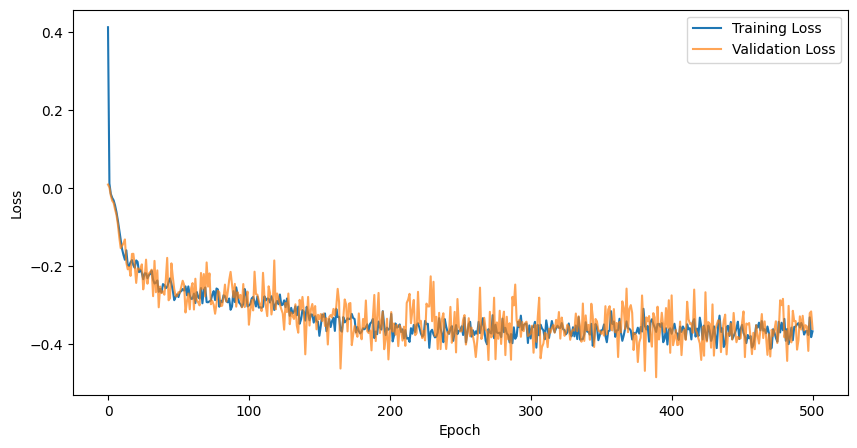

In [8]:
# Model parameters
input_dim = 2
hidden_dim = 512
n_steps = 500
n_traj = 2000
n_epochs = 501

m = [[2, 14], 
        [8, 8]]

s = [[[0.3, 0.1], [0.3, 0.5]],
     [[1.0, 0.5], [0.5, 1.0]]] 

w = [0.3, 0.7]

# Create network and embedding
net = create_network(input_dim, hidden_dim)
time_embed = nn.Sequential(nn.Linear(1, input_dim))

# Prepare data
train_loader, val_loader, test_loader, gmm_samples = prepare_data(
    n_traj=n_traj,
    weights=w,
    means=m,
    sds=s
)

# Train model
train_losses, val_losses = train_model(net, time_embed, train_loader, val_loader, n_epochs)
#plot_training_results(train_losses, val_losses, debug_metrics)

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', alpha = 0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
def produce_samples(net, time_embed,test_data, num_timesteps=1000, eps=1e-5):

    num_samples = len(test_data)

    # Forward process timesteps (0,2)
    forward_ts = torch.linspace(0., 2., num_timesteps)
    forward_states = []

    # Generate forward process states
    x0 = test_data[:num_samples].unsqueeze(-1)
    forward_states.append(x0.detach().numpy().copy())  # t=0 state

    with torch.no_grad():
        for t in forward_ts[1:]:  # Start from second time point since we already have t=0
            perturbed = sample_pt(x0, t)
            forward_states.append(perturbed.detach().numpy().copy())

    # Start reverse process with the exact same samples from forward process end
    x = torch.tensor(forward_states[-1], dtype=torch.float32)
    
    # Reverse process timesteps (2, 0)
    reverse_ts = torch.linspace(2., eps, num_timesteps)
    dt = reverse_ts[1] - reverse_ts[0]
    
    # Store reverse process states
    reverse_states = [x.numpy().copy()]

    score_approx = []
    score_truth = []
    
    # Perform reverse SDE
    with torch.no_grad():
        for i in range(len(reverse_ts)-1):
            t = reverse_ts[i]
            t_batch = torch.full((x.shape[0], 1), t)
            t_embed = time_embed(t_batch)

            x = x.squeeze(-1)
            score = net(torch.cat([x, t_embed], dim=1))

            score_t = compute_score(x, t)

            score_approx.append(score.mean().item())
            score_truth.append(score_t.mean().item())
            
            g_t = diffusion(t)
            drift = -(g_t**2) * score
            noise = g_t * torch.randn_like(x) * torch.sqrt(torch.abs(dt))
            x = x + (drift * dt) + noise
            
            reverse_states.append(x.detach().numpy().copy())

    return forward_states, reverse_states, score_approx, score_truth

# test data split
test_data_new = []
for batch in test_loader:
    test_data_new.append(batch[0].squeeze())
test_data_new = torch.cat(test_data_new)

# After training
f, r, approx_scores, true_scores = produce_samples(net, time_embed, test_data_new, num_timesteps= 1000)

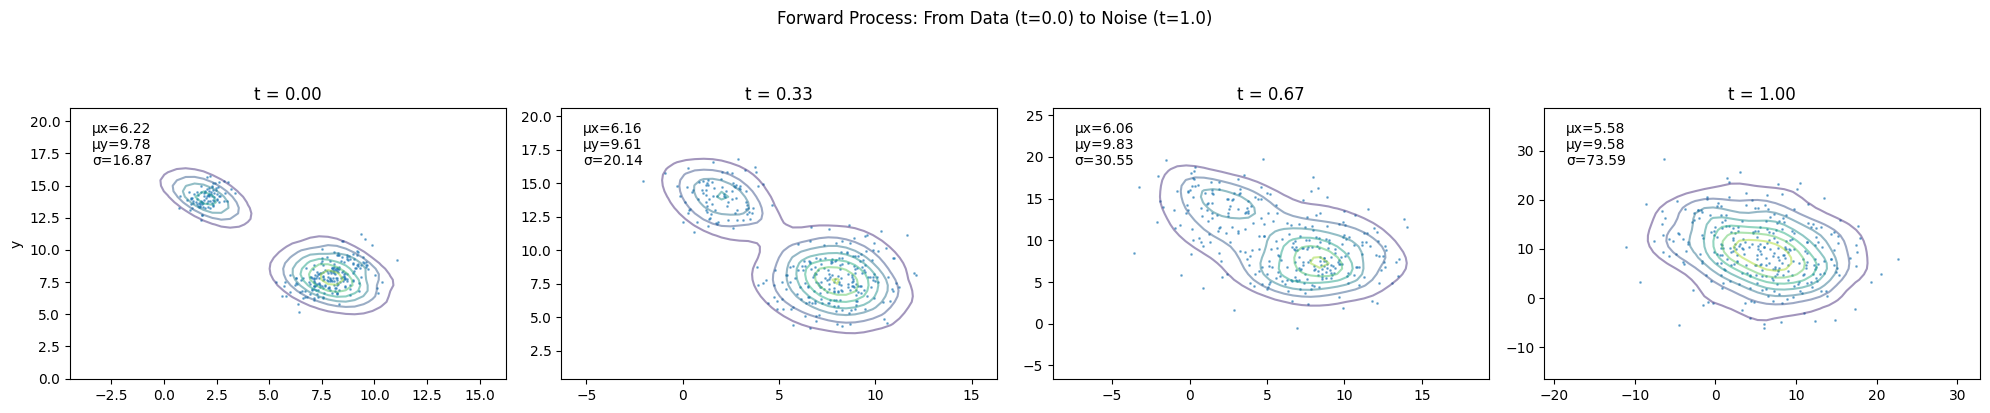

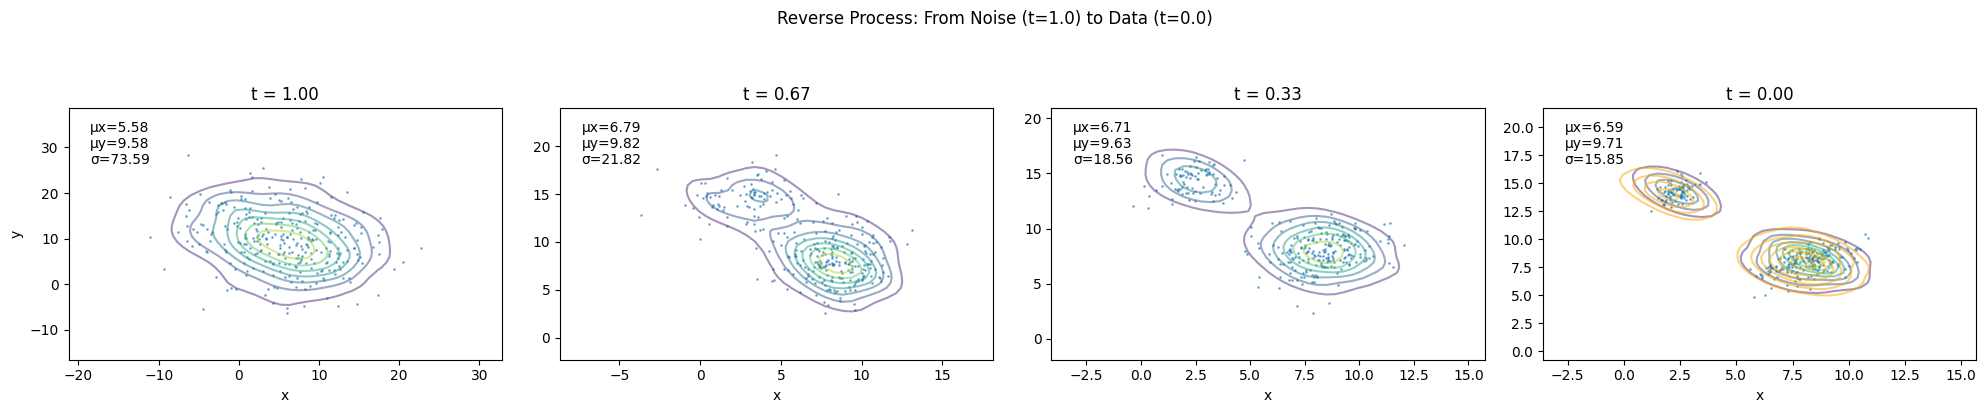

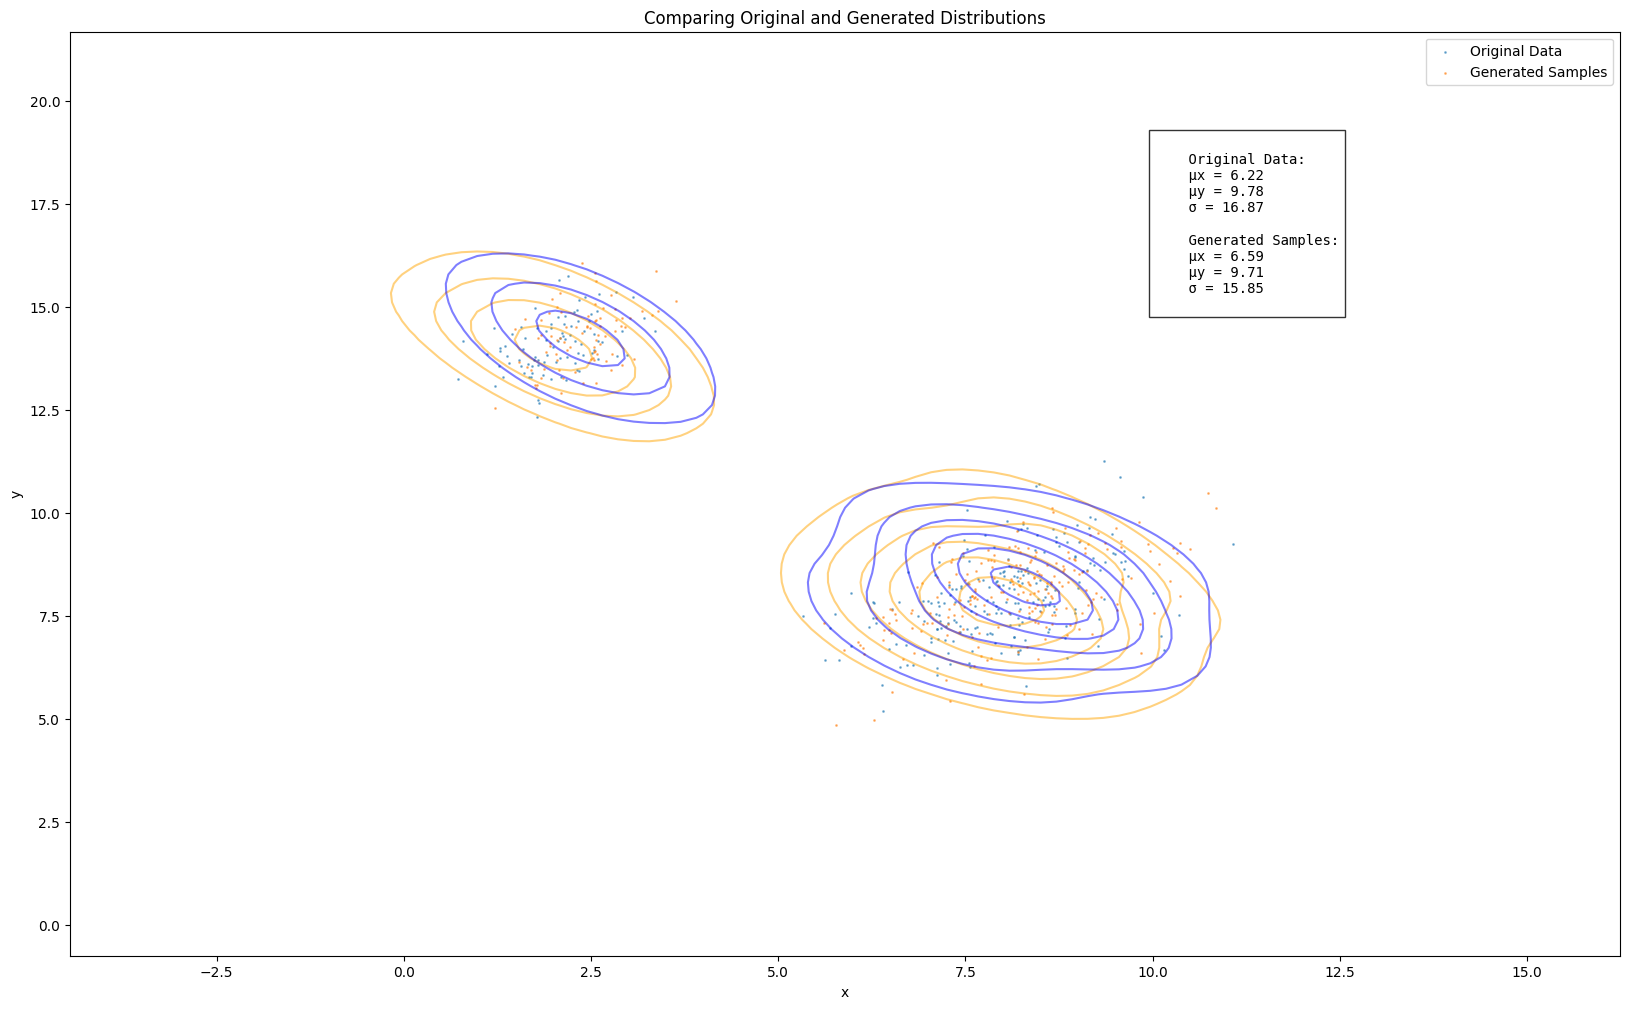

In [10]:
from scipy.stats import gaussian_kde

def plot_diffusion_process(forward_states, reverse_states, num_timesteps=8, eps=1e-5):
    def to_numpy(data):
        if torch.is_tensor(data):
            return data.detach().cpu().numpy()
        return data
    
    def compute_kde(x, y):
        try:
            # Ensure data is properly shaped and has enough samples
            x = x.reshape(-1)  # Flatten x
            y = y.reshape(-1)  # Flatten y
            data = np.vstack([x, y])
            # Check we have enough samples
            if data.shape[1] < 3:  # Need at least 3 points
                return None
            # Add small noise for stability
            data += np.random.normal(0, 1e-6, data.shape)
            return gaussian_kde(data)
        except Exception as e:
            print(f"Warning: KDE failed: {str(e)}")
            return None

    def compute_cov(x, y):
        try:
            # Ensure proper reshaping and stacking
            x = x.reshape(-1)  # Flatten x
            y = y.reshape(-1)  # Flatten y
            data = np.array([x, y])  # Stack as 2xN matrix
            # Add regularization
            cov = np.cov(data) + np.eye(2) * 1e-6
            return cov
        except Exception as e:
            print(f"Warning: Covariance computation failed: {str(e)}")
            return np.eye(2) * 1e-6
    
    # Get all data points for global min/max
    all_forward_samples = [to_numpy(forward_states[i]) for i in range(len(forward_states))]
    all_reverse_samples = [to_numpy(reverse_states[i]) for i in range(len(reverse_states))]
    
    total_steps = len(forward_states)
    indices = [int(i * (total_steps-1)/(num_timesteps-1)) for i in range(num_timesteps)]
    reverse_indices = [int(i * (total_steps-1)/(num_timesteps-1)) for i in range(num_timesteps)]

    n_rows = (num_timesteps + 3) // 4
    n_cols = min(4, num_timesteps)
    
    forward_ts = torch.linspace(0., 1., num_timesteps)
    
    # Plot forward process
    plt.figure(figsize=(20, 4))
    
    # Pre-compute all KDE contours to determine appropriate limits
    forward_kdes = []
    forward_contour_ranges = []
    
    for idx in range(num_timesteps):
        f_samples = to_numpy(forward_states[indices[idx]])
        x = f_samples[:, 0]
        y = f_samples[:, 1]
        kernel = compute_kde(x, y)
        
        # Calculate appropriate margins based on position in sequence
        # First plot (t=0.00) needs extra room on the left
        margin_factor = 0.5 if idx == 0 else 0.3
        
        x_margin = (x.max() - x.min()) * margin_factor
        y_margin = (y.max() - y.min()) * margin_factor
        
        x_min = x.min() - x_margin
        x_max = x.max() + x_margin
        y_min = y.min() - y_margin
        y_max = y.max() + y_margin
        
        forward_kdes.append(kernel)
        forward_contour_ranges.append((x_min, x_max, y_min, y_max))
    
    # Plot forward process with improved limits
    for idx in range(num_timesteps):
        plt.subplot(n_rows, n_cols, idx + 1)
        f_samples = to_numpy(forward_states[indices[idx]])
        
        x = f_samples[:, 0]
        y = f_samples[:, 1]
        
        # Use pre-computed limits that guarantee no cutoff
        x_min, x_max, y_min, y_max = forward_contour_ranges[idx]
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        
        plt.scatter(x, y, alpha=0.5, s=1)
        
        # Draw contours
        kernel = forward_kdes[idx]
        if kernel is not None:
            xi = np.linspace(x_min, x_max, 50)
            yi = np.linspace(y_min, y_max, 50)
            xi, yi = np.meshgrid(xi, yi)
            
            positions = np.vstack([xi.ravel(), yi.ravel()])
            z = np.reshape(kernel(positions).T, xi.shape)
            plt.contour(xi, yi, z, alpha=0.5)
        
        t_val = forward_ts[idx].item()
        plt.title(f't = {t_val:.2f}')
        
        if idx % n_cols == 0:
            plt.ylabel('y')
        if idx >= len(forward_states) - n_cols:
            plt.xlabel('x')
        
        mean_x, mean_y = np.mean(x), np.mean(y)
        cov = compute_cov(x, y)
        plt.text(0.05, 0.95, f'μx={mean_x:.2f}\nμy={mean_y:.2f}\nσ={np.trace(cov):.2f}',
                transform=plt.gca().transAxes,
                verticalalignment='top')
    
    plt.suptitle('Forward Process: From Data (t=0.0) to Noise (t=1.0)', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Reverse process timesteps
    reverse_ts = torch.linspace(1., eps, num_timesteps)
    
    # Pre-compute all KDE contours for reverse process
    reverse_kdes = []
    reverse_contour_ranges = []
    
    for idx in range(num_timesteps):
        r_samples = to_numpy(reverse_states[reverse_indices[idx]])
        x = r_samples[:, 0]
        y = r_samples[:, 1]
        kernel = compute_kde(x, y)
        
        # Last plot (t=0.00) needs extra room on the right
        margin_factor = 0.5 if idx == (num_timesteps-1) else 0.3
        
        x_margin = (x.max() - x.min()) * margin_factor
        y_margin = (y.max() - y.min()) * margin_factor
        
        x_min = x.min() - x_margin
        x_max = x.max() + x_margin
        y_min = y.min() - y_margin
        y_max = y.max() + y_margin
        
        reverse_kdes.append(kernel)
        reverse_contour_ranges.append((x_min, x_max, y_min, y_max))
    
    plt.figure(figsize=(20, 4*n_rows))
    for idx in range(num_timesteps):
        plt.subplot(n_rows, n_cols, idx + 1)
        r_samples = to_numpy(reverse_states[reverse_indices[idx]])
        
        x = r_samples[:, 0]
        y = r_samples[:, 1]
        
        # Use pre-computed limits to avoid cutoff
        x_min, x_max, y_min, y_max = reverse_contour_ranges[idx]
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        
        plt.scatter(x, y, alpha=0.5, s=1)
        
        kernel = reverse_kdes[idx]
        if kernel is not None:
            xi = np.linspace(x_min, x_max, 50)
            yi = np.linspace(y_min, y_max, 50)
            xi, yi = np.meshgrid(xi, yi)
            
            positions = np.vstack([xi.ravel(), yi.ravel()])
            z = np.reshape(kernel(positions).T, xi.shape)
            plt.contour(xi, yi, z, alpha=0.5)
            
            if idx == num_timesteps-1:
                orig_x = to_numpy(forward_states[0])[:, 0]
                orig_y = to_numpy(forward_states[0])[:, 1]
                kernel_orig = compute_kde(orig_x, orig_y)
                if kernel_orig is not None:
                    z_orig = np.reshape(kernel_orig(positions).T, xi.shape)
                    plt.contour(xi, yi, z_orig, alpha=0.5, colors='orange')
        
        t_val = reverse_ts[idx].item()
        plt.title(f't = {t_val:.2f}')
        
        if idx % n_cols == 0:
            plt.ylabel('y')
        if idx >= num_timesteps - n_cols:
            plt.xlabel('x')
        
        mean_x, mean_y = np.mean(x), np.mean(y)
        cov = compute_cov(x, y)
        plt.text(0.05, 0.95, f'μx={mean_x:.2f}\nμy={mean_y:.2f}\nσ={np.trace(cov):.2f}',
                transform=plt.gca().transAxes,
                verticalalignment='top')
    
    plt.suptitle('Reverse Process: From Noise (t=1.0) to Data (t=0.0)', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Final comparison plot
    plt.figure(figsize=(20, 12))
    
    # Original data
    orig_samples = to_numpy(forward_states[0])
    x_orig = orig_samples[:, 0]
    y_orig = orig_samples[:, 1]
    plt.scatter(x_orig, y_orig, alpha=0.5, label='Original Data', s=1)
    
    # Generated samples
    gen_samples = to_numpy(reverse_states[-1])
    x_gen = gen_samples[:, 0]
    y_gen = gen_samples[:, 1]
    plt.scatter(x_gen, y_gen, alpha=0.5, label='Generated Samples', s=1)
    
    # Add contours for both distributions
    kernel_orig = compute_kde(x_orig, y_orig)
    kernel_gen = compute_kde(x_gen, y_gen)
    
    if kernel_orig is not None and kernel_gen is not None:
        # Get the ranges of both distributions
        xmin = min(x_orig.min(), x_gen.min())
        xmax = max(x_orig.max(), x_gen.max())
        ymin = min(y_orig.min(), y_gen.min())
        ymax = max(y_orig.max(), y_gen.max())
        
        # Calculate a much larger margin for KDE contours (50% of range)
        x_margin = (xmax - xmin) * 0.5
        y_margin = (ymax - ymin) * 0.5
        
        # Expand the grid beyond data points to capture KDE contours fully
        xi_min = xmin - x_margin
        xi_max = xmax + x_margin
        yi_min = ymin - y_margin
        yi_max = ymax + y_margin
        
        # Set plot limits to match expanded grid
        plt.xlim(xi_min, xi_max)
        plt.ylim(yi_min, yi_max)
        
        # Create grid for KDE
        xi = np.linspace(xi_min, xi_max, 100)  # Increased resolution
        yi = np.linspace(yi_min, yi_max, 100)
        xi, yi = np.meshgrid(xi, yi)
        positions = np.vstack([xi.ravel(), yi.ravel()])
        
        # Calculate KDE values
        z_orig = np.reshape(kernel_orig(positions).T, xi.shape)
        z_gen = np.reshape(kernel_gen(positions).T, xi.shape)
        
        # Limit number of contour levels for cleaner visualization
        levels = 6
        plt.contour(xi, yi, z_orig, levels=levels, alpha=0.5, colors='orange')
        plt.contour(xi, yi, z_gen, levels=levels, alpha=0.5, colors='blue')
    
    plt.title('Comparing Original and Generated Distributions')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    
    stats_text = f"""
    Original Data:
    μx = {np.mean(x_orig):.2f}
    μy = {np.mean(y_orig):.2f}
    σ = {np.trace(compute_cov(x_orig, y_orig)):.2f}
    
    Generated Samples:
    μx = {np.mean(x_gen):.2f}
    μy = {np.mean(y_gen):.2f}
    σ = {np.trace(compute_cov(x_gen, y_gen)):.2f}
    """
    plt.text(0.7, 0.7, stats_text, transform=plt.gca().transAxes,
            fontsize=10, family='monospace', bbox=dict(facecolor='white', alpha=0.8))
    
    #plt.tight_layout(pad=2.0)  # Increased padding
    plt.show()

plot_diffusion_process(f, r, num_timesteps=4)